# Agri-Guard AI Initial Prototype

This notebook explores the agricultural dataset and begins building a simple production prediction prototype for the ML track demo.

Sections: introduction, load data, exploration, visualization, cleaning, modeling, and evaluation.

## 1. Introduction

Agri-Guard AI is an initial prototype using historical Ghana agricultural production data to predict expected crop production and support farm planning.

The dataset includes district-level and region-level crop production values alongside a year-to-year comparison file.

In [1]:
import pandas as pd
from pathlib import Path


def find_data_dir():
    path = Path.cwd()
    for _ in range(8):
        candidate = path / 'data' / 'agri_guard_csvs'
        if candidate.exists():
            return candidate
        path = path.parent
    raise FileNotFoundError(
        f'Could not locate data/agri_guard_csvs from {Path.cwd()}.\n'
        'Make sure the notebook is opened in the repository root or adjust the path.'
    )

DATA_DIR = find_data_dir()
DISTRICTS_PATH = DATA_DIR / 'DISTRICTS.csv'
REGIONS_PATH = DATA_DIR / 'REGIONS.csv'
COMPARISON_PATH = DATA_DIR / 'COMPARISION.csv'

print('DATA_DIR resolved to:', DATA_DIR)
print('DISTRICTS file exists:', DISTRICTS_PATH.exists())
print('REGIONS file exists:', REGIONS_PATH.exists())
print('COMPARISON file exists:', COMPARISON_PATH.exists())


DATA_DIR resolved to: C:\Users\awini\agri-guard-ai\data\agri_guard_csvs
DISTRICTS file exists: True
REGIONS file exists: True
COMPARISON file exists: True


## 2. Load Data

The CSV files contain title rows above the actual headers, so we load them with `header=1` to use the correct column names.

In [2]:
districts = pd.read_csv(DISTRICTS_PATH, header=1)
regions = pd.read_csv(REGIONS_PATH, header=1)
comparison = pd.read_csv(COMPARISON_PATH, header=1, skiprows=[2])

districts.head()
regions.head()
comparison.head()

,REGION,Maize,Unnamed: 2,Unnamed: 3,Rice,Unnamed: 5,Unnamed: 6,Millet,Unnamed: 8,Unnamed: 9,...,REGION.1,G'nuts,Unnamed: 32,Unnamed: 33,Cowpea,Unnamed: 35,Unnamed: 36,Soyabean,Unnamed: 38,Unnamed: 39
0,WESTERN,50720,50120.00,-1.1829652996845426,17130,17410.000000,1.6345592527729131,0,0.0,NaN,...,WESTERN,0,0.0,NaN,0,0.0,NaN,0,0.0,NaN
1,CENTRAL,103070,104600.51,1.484922867953813,4290,4328.364561,0.8942788205946052,0,0.0,NaN,...,CENTRAL,0,0.0,NaN,0,0.0,NaN,0,0.0,NaN
2,EASTERN,173050,174573.20,0.8802080323605962,6630,6655.000000,0.3770739064856712,0,0.0,NaN,...,EASTERN,8216,0.0,NaN,1930,0.0,NaN,0,0.0,NaN
3,GREATER ACCRA,3638,3930.69,8.045354590434306,2322.63,2909.310000,25.25929657328114,0,0.0,NaN,...,GREATER ACCRA,0,0.0,NaN,0,0.0,NaN,0,0.0,NaN
4,VOLTA,52070,53923.00,3.558671019781064,21860,22759.000000,4.112534309240623,0,0.0,NaN,...,VOLTA,0,0.0,NaN,1920,1973.2,2.7708333333333357,4360,4337.2,-0.522935779816518


## 3. Data Exploration

Inspect the loaded tables to understand the dataset structure, basic statistics, and possible cleaning needs.

In [3]:
for name, df in [('districts', districts), ('regions', regions), ('comparison', comparison)]:
    print(f'\n=== {name} ===')
    print('shape:', df.shape)
    print('columns:', df.columns.tolist())
    display(df.head())


=== districts ===
shape: (586, 14)
columns: ['DISTRICTS', 'MAIZE', 'RICE', 'CASSAVA', 'YAM', 'COCOYAM', 'PLANTAIN', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13']


,DISTRICTS,MAIZE,RICE,CASSAVA,YAM,COCOYAM,PLANTAIN,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,Shama Ahanta East,1000,140,2400,30,60,350,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,West Ahanta,1450,110,4000,30,200,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Mporhor Wassa East,2100,120,5750,200,1600,1750,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Wassa West,2200,1390,4000,180,600,1150,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,East Nzema,1620,610,5850,30,100,350,NaN,NaN,NaN,NaN,NaN,NaN,NaN



=== regions ===
shape: (44, 12)
columns: ['REGION', 'MAIZE', 'RICE', 'MILLET', 'SORGHUM', 'CASSAVA', 'YAM', 'COCOYAM', 'PLANTAIN', "G'NUTS", 'COWPEA', 'SOYABEAN']


,REGION,MAIZE,RICE,MILLET,SORGHUM,CASSAVA,YAM,COCOYAM,PLANTAIN,G'NUTS,COWPEA,SOYABEAN
0,WESTERN,50120,17410,NaN,NaN,73250,10150,37810,56850,NaN,NaN,NaN
1,CENTRAL,104600.51,4328.364561403509,NaN,NaN,122274.86,2818.2999999999997,15944,17862.4,NaN,NaN,NaN
2,EASTERN,174573.2,6655,NaN,NaN,186165,39209,31017.77,84768.04000000001,NaN,NaN,NaN
3,GREATER ACCRA,3930.69,2909.31,NaN,NaN,6741.5,NaN,NaN,NaN,NaN,NaN,NaN
4,VOLTA,53923,22759,NaN,4403.6,105169,27355.5,6268.1,7899.4,NaN,1973.2,4337.2



=== comparison ===
shape: (96, 40)
columns: ['REGION', 'Maize', 'Unnamed: 2', 'Unnamed: 3', 'Rice', 'Unnamed: 5', 'Unnamed: 6', 'Millet', 'Unnamed: 8', 'Unnamed: 9', 'Sorghum', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29', 'REGION.1', "G'nuts", 'Unnamed: 32', 'Unnamed: 33', 'Cowpea', 'Unnamed: 35', 'Unnamed: 36', 'Soyabean', 'Unnamed: 38', 'Unnamed: 39']


,REGION,Maize,Unnamed: 2,Unnamed: 3,Rice,Unnamed: 5,Unnamed: 6,Millet,Unnamed: 8,Unnamed: 9,...,REGION.1,G'nuts,Unnamed: 32,Unnamed: 33,Cowpea,Unnamed: 35,Unnamed: 36,Soyabean,Unnamed: 38,Unnamed: 39
0,WESTERN,50720,50120.00,-1.1829652996845426,17130,17410.000000,1.6345592527729131,0,0.0,NaN,...,WESTERN,0,0.0,NaN,0,0.0,NaN,0,0.0,NaN
1,CENTRAL,103070,104600.51,1.484922867953813,4290,4328.364561,0.8942788205946052,0,0.0,NaN,...,CENTRAL,0,0.0,NaN,0,0.0,NaN,0,0.0,NaN
2,EASTERN,173050,174573.20,0.8802080323605962,6630,6655.000000,0.3770739064856712,0,0.0,NaN,...,EASTERN,8216,0.0,NaN,1930,0.0,NaN,0,0.0,NaN
3,GREATER ACCRA,3638,3930.69,8.045354590434306,2322.63,2909.310000,25.25929657328114,0,0.0,NaN,...,GREATER ACCRA,0,0.0,NaN,0,0.0,NaN,0,0.0,NaN
4,VOLTA,52070,53923.00,3.558671019781064,21860,22759.000000,4.112534309240623,0,0.0,NaN,...,VOLTA,0,0.0,NaN,1920,1973.2,2.7708333333333357,4360,4337.2,-0.522935779816518


## 4. Visualizations

Create simple charts to show crop totals and region comparisons.

Examples: production by crop, production by region, year-over-year comparison.

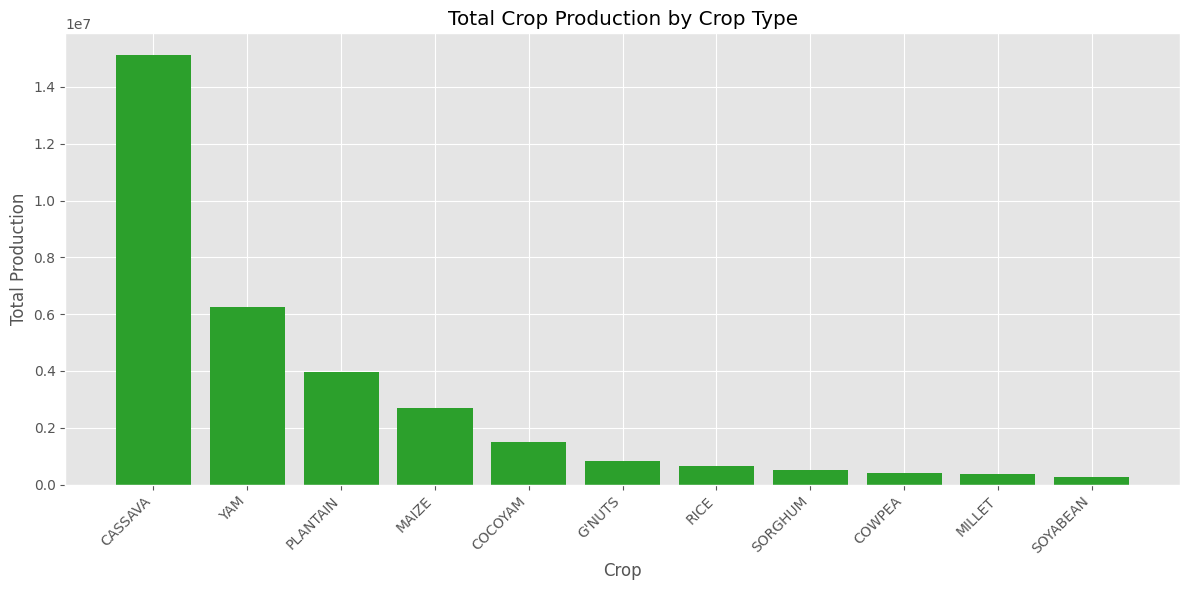

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt

try:
    plt.style.use('seaborn-whitegrid')
except OSError:
    plt.style.use('ggplot')

# Clean the region data for plotting
plot_regions = regions.copy()
plot_regions = plot_regions[~plot_regions['REGION'].astype(str).str.strip().str.contains(r'PRODUCTION|TOTAL|REGION', case=False, na=False)]

crop_columns = [col for col in plot_regions.columns if col not in ['REGION']]
for col in crop_columns:
    plot_regions[col] = pd.to_numeric(
        plot_regions[col].astype(str).str.replace(',', '', regex=False).str.strip(),
        errors='coerce'
    )

crop_totals = plot_regions[crop_columns].sum(skipna=True).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(crop_totals.index, crop_totals.values, color='tab:green')
plt.xticks(rotation=45, ha='right')
plt.title('Total Crop Production by Crop Type')
plt.ylabel('Total Production')
plt.xlabel('Crop')
plt.tight_layout()
plt.show()


## 5. Data Cleaning and Modeling

Prepare the region-level dataset for a simple regression prototype. We will predict total `MAIZE` production using the other crop production values in the region dataset.


Test RMSE: 148854.69
Test R2: -2.766
Feature importances:


MILLET      25.832782
COWPEA      16.626141
SORGHUM    -12.123280
G'NUTS     -10.781397
COCOYAM      1.811465
SOYABEAN    -0.908070
RICE        -0.636892
PLANTAIN    -0.533573
YAM          0.112981
CASSAVA      0.061284
dtype: float64


Top 5 prediction errors:


,REGION,actual_MAIZE,predicted_MAIZE,error,abs_error
9,UPPER EAST,43370.000000,351091.726194,307721.726194,307721.726194
8,UPPER WEST,67350.000000,266398.574210,199048.574210,199048.574210
21,ASHANTI,173734.520200,307040.951404,133306.431204,133306.431204
23,NORTHERN,192604.113472,223052.026475,30447.913003,30447.913003
39,NORTHERN,1.429635,26434.871956,26433.442321,26433.442321


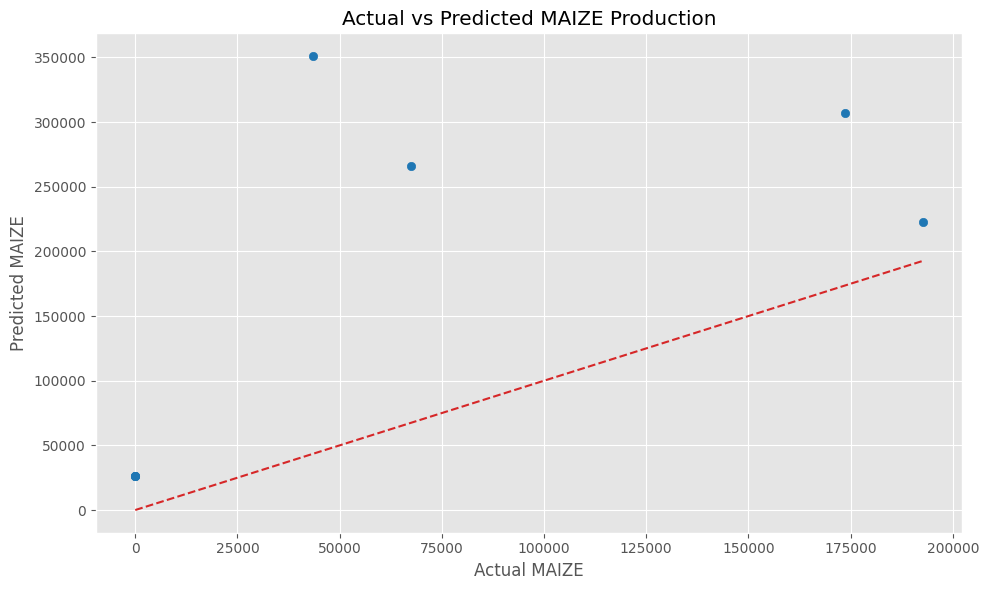

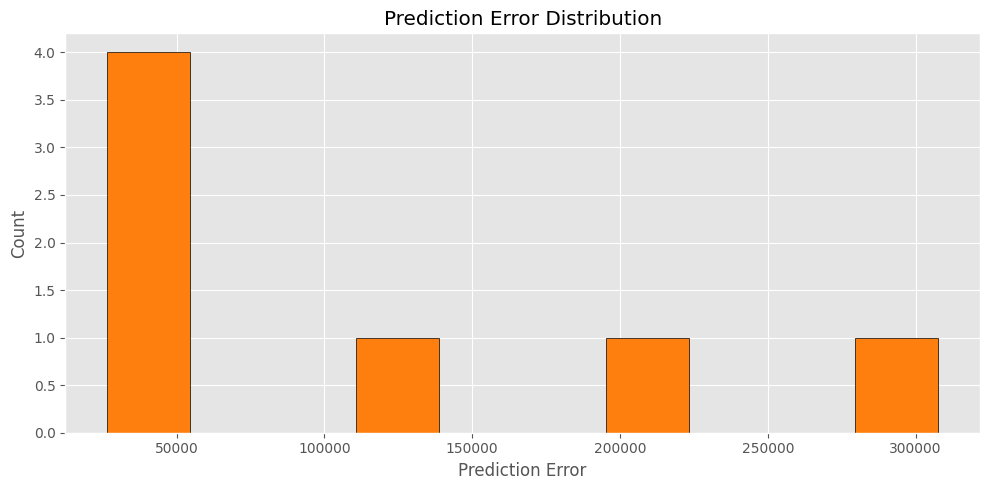

,REGION,actual_MAIZE,predicted_MAIZE,error,abs_error
23,NORTHERN,192604.113472,223052.026475,30447.913003,30447.913003
21,ASHANTI,173734.520200,307040.951404,133306.431204,133306.431204
8,UPPER WEST,67350.000000,266398.574210,199048.574210,199048.574210
9,UPPER EAST,43370.000000,351091.726194,307721.726194,307721.726194
41,UPPER EAST,1.735603,26413.462595,26411.726992,26411.726992
39,NORTHERN,1.429635,26434.871956,26433.442321,26433.442321
35,GREATER ACCRA,1.134979,26402.677718,26401.542739,26401.542739


In [5]:
# Prepare the region-level dataset for modeling
region_model = regions.copy()

# Remove blank rows, repeated header rows, totals, and footer text
valid_region = region_model['REGION'].astype(str).str.strip()
invalid_mask = (
    valid_region.isna()
    | valid_region.eq('')
    | valid_region.str.contains(r'PRODUCTION|TOTAL|REGION', case=False, na=False)
)
region_model = region_model[~invalid_mask].copy()

# Convert crop columns to numeric and replace missing values with 0
numeric_cols = [col for col in region_model.columns if col != 'REGION']
for col in numeric_cols:
    region_model[col] = pd.to_numeric(
        region_model[col].astype(str).str.replace(',', '', regex=False).str.strip(),
        errors='coerce'
    )

region_model = region_model.dropna(subset=['MAIZE'])
region_model = region_model.fillna(0)

region_names = region_model['REGION'].copy()
region_model = region_model.drop(columns=['REGION'])

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = region_model.drop(columns=['MAIZE'])
y = region_model['MAIZE']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print('Test RMSE:', round(rmse, 2))
print('Test R2:', round(r2, 3))

feature_coeffs = pd.Series(model.coef_, index=X.columns)
feature_importance = feature_coeffs.abs().sort_values(ascending=False)
print('Feature importances:')
display(feature_coeffs.reindex(feature_importance.index))

predictions = pd.DataFrame({
    'REGION': region_names.loc[y_test.index],
    'actual_MAIZE': y_test,
    'predicted_MAIZE': y_pred
})
predictions = predictions.sort_values('actual_MAIZE', ascending=False)

# Add error columns for evaluation
predictions['error'] = predictions['predicted_MAIZE'] - predictions['actual_MAIZE']
predictions['abs_error'] = predictions['error'].abs()

print('\nTop 5 prediction errors:')
display(predictions.sort_values('abs_error', ascending=False).head())

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(predictions['actual_MAIZE'], predictions['predicted_MAIZE'], color='tab:blue')
plt.plot([predictions['actual_MAIZE'].min(), predictions['actual_MAIZE'].max()],
         [predictions['actual_MAIZE'].min(), predictions['actual_MAIZE'].max()],
         color='tab:red', linestyle='--')
plt.title('Actual vs Predicted MAIZE Production')
plt.xlabel('Actual MAIZE')
plt.ylabel('Predicted MAIZE')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(predictions['error'], bins=10, color='tab:orange', edgecolor='black')
plt.title('Prediction Error Distribution')
plt.xlabel('Prediction Error')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

display(predictions)


## 6. District-Level Modeling

Build a district-level crop production model using the Western region district dataset. This section cleans the district data, trains a model for `MAIZE`, and evaluates prediction quality.

District test RMSE: 5661.14
District test R2: 0.482

Top district feature importances:


YAM         0.446972
CASSAVA     0.184471
PLANTAIN    0.138837
RICE        0.132317
COCOYAM     0.097404
dtype: float64

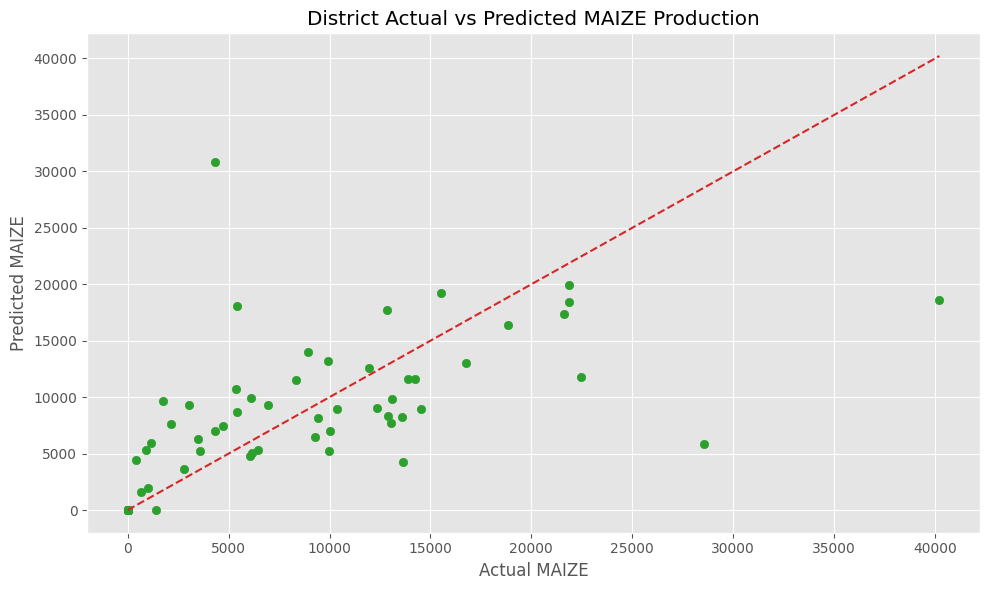

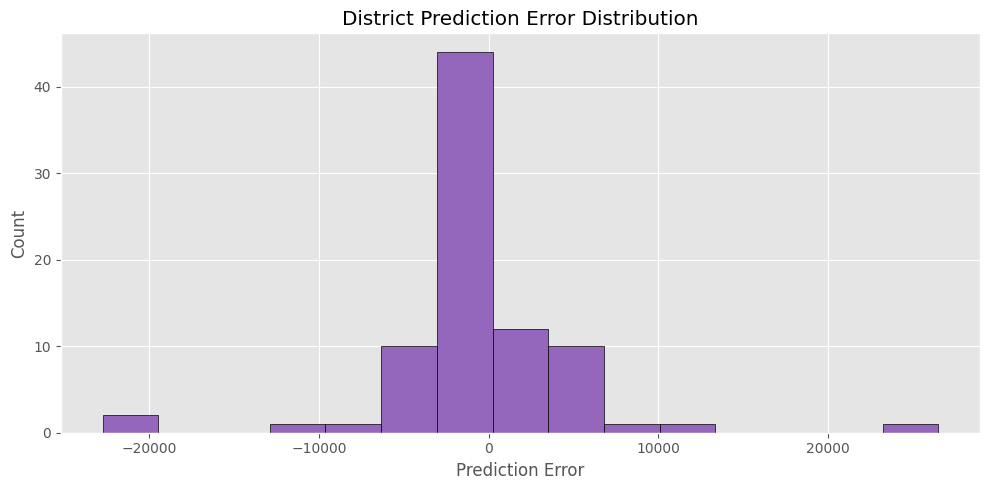

,DISTRICT,actual_MAIZE,predicted_MAIZE,error,abs_error
523,Wa Municipal,1.250000,1.27000,0.020000,0.020000
23,East Nzema,1.330000,1.30922,-0.020780,0.020780
28,Bibiani-Anhwiaso-Bekwai,1.420000,1.39326,-0.026740,0.026740
317,Atwima Mponua,1.200000,1.24140,0.041400,0.041400
521,Wa West,1.200000,1.15020,-0.049800,0.049800
402,Pru,1.740000,1.79090,0.050900,0.050900
21,Mporhor Wassa East,1.320000,1.26800,-0.052000,0.052000
386,Asutifi,1.820000,1.76382,-0.056180,0.056180
385,Sunyani,1.750000,1.81899,0.068990,0.068990
199,AMA,1.528814,1.45890,-0.069914,0.069914


In [6]:
# District-level data preparation and model training
district_model = districts.copy()

# Remove blank rows, repeated headers, totals, and footer text
valid_district = district_model['DISTRICTS'].astype(str).str.strip()
invalid_mask = (
    valid_district.isna()
    | valid_district.eq('')
    | valid_district.str.contains(r'PRODUCTION|TOTAL|AVERAGE|DISTRICTS', case=False, na=False)
)
district_model = district_model[~invalid_mask].copy()

# Drop unnamed trailing columns that have no useful crop data
district_model = district_model.drop(columns=[col for col in district_model.columns if col.startswith('Unnamed')])

numeric_cols = [
    col for col in district_model.columns
    if col != 'DISTRICTS'
]

for col in numeric_cols:
    district_model[col] = pd.to_numeric(
        district_model[col]
        .astype(str)
        .str.replace(',', '', regex=False)
        .str.strip()
        .replace({'-': None, '': None, 'nan': None}),
        errors='coerce'
    )

# Remove any rows that don't have valid MAIZE values after conversion
district_model = district_model.dropna(subset=['MAIZE'])

# Remove any numeric columns that are entirely empty after cleaning
empty_numeric_cols = [
    col for col in district_model.columns
    if col != 'DISTRICTS' and col != 'MAIZE' and district_model[col].isna().all()
]
if empty_numeric_cols:
    district_model = district_model.drop(columns=empty_numeric_cols)

# Fill missing crop values with 0 for modeling
district_model = district_model.fillna(0)

district_names = district_model['DISTRICTS'].copy()
district_model = district_model.drop(columns=['DISTRICTS'])

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

X = district_model.drop(columns=['MAIZE'])
y = district_model['MAIZE']

# Explicitly ensure X columns are numeric before fitting
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
district_model_rf = RandomForestRegressor(random_state=42, n_estimators=100)
district_model_rf.fit(X_train, y_train)

y_pred = district_model_rf.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print('District test RMSE:', round(rmse, 2))
print('District test R2:', round(r2, 3))

feature_importance = pd.Series(
    district_model_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print('\nTop district feature importances:')
display(feature_importance.head(10))

predictions = pd.DataFrame({
    'DISTRICT': district_names.loc[y_test.index],
    'actual_MAIZE': y_test,
    'predicted_MAIZE': y_pred
})
predictions['error'] = predictions['predicted_MAIZE'] - predictions['actual_MAIZE']
predictions['abs_error'] = predictions['error'].abs()

plt.figure(figsize=(10, 6))
plt.scatter(predictions['actual_MAIZE'], predictions['predicted_MAIZE'], color='tab:green')
plt.plot([
    predictions['actual_MAIZE'].min(), predictions['actual_MAIZE'].max()],
    [predictions['actual_MAIZE'].min(), predictions['actual_MAIZE'].max()],
    color='tab:red', linestyle='--'
)
plt.title('District Actual vs Predicted MAIZE Production')
plt.xlabel('Actual MAIZE')
plt.ylabel('Predicted MAIZE')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(predictions['error'], bins=15, color='tab:purple', edgecolor='black')
plt.title('District Prediction Error Distribution')
plt.xlabel('Prediction Error')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

display(predictions.sort_values('abs_error').head(10))
